# Session 37b · Agentic RAG

**Phase 10 — AI Agents · Fully practical, live-coded · Local LLM + local vector store only**

In the first notebook, the *shape* of the workflow was fixed at build time: research, then
write, then review, then publish, always in that order. Retrieval-augmented generation (RAG)
usually gets built the same way — retrieve, then generate, always, for every question, whether
it needs it or not. This notebook builds a RAG agent that doesn't take that shape for granted.
It **decides**, per question: do I even need to search? If I search and the results are weak,
should I try again with a better query, or give up honestly? Every one of those is a judgement
call the graph makes at runtime, not a step you hard-coded in advance — that's what makes it
*agentic* RAG rather than plain RAG.

By the end of this notebook you will have built:

* a real local knowledge base — five actual AI-agent research papers, chunked and embedded
* a **retriever tool** over a **local vector store** (Chroma) — no hosted vector DB
* an agent step that decides whether retrieval is necessary **before** doing it
* a **relevance grading** step that looks at what came back and judges whether it's enough
* a **query rewriting** step that reformulates the question when the first search falls short
* a **retry loop**, wired with LangGraph's conditional routing, bounded so it can't spin forever
* a final answer that is **grounded** — cited to the actual source passages, and honest when
  the knowledge base genuinely doesn't contain the answer

**Everything here runs locally.** The chat model is `llama3.2:3b` and the embedding model is
`nomic-embed-text`, both served by Ollama; the vector store is a Chroma collection persisted to
a folder on disk. No API key, no network dependency once the papers are downloaded.


## 0 · Setup

Same local stack as the LangGraph-II notebook, plus a local embedding model and a local vector
store library.

```bash
pip install langgraph langchain langchain-ollama langchain-chroma chromadb langchain-text-splitters pymupdf
ollama pull llama3.2:3b
ollama pull nomic-embed-text
ollama serve
```


In [1]:
import json
import time
import requests

OLLAMA_HOST = "http://127.0.0.1:11434"
CHAT_MODEL = "llama3.2:3b"
EMBED_MODEL = "nomic-embed-text"

try:
    r = requests.get(f"{OLLAMA_HOST}/api/version", timeout=3)
    r.raise_for_status()
    print(f"Ollama server is up (version {r.json()['version']}).")
except Exception as e:
    raise RuntimeError("Can't reach Ollama. Run `ollama serve` in a terminal, then re-run this cell.") from e

tags = requests.get(f"{OLLAMA_HOST}/api/tags", timeout=3).json()
available = [m["name"] for m in tags.get("models", [])]
for needed in (CHAT_MODEL, EMBED_MODEL):
    if not any(needed in name for name in available):
        raise RuntimeError(f"Model '{needed}' is not pulled. Run `ollama pull {needed}`, then re-run this cell.")
print(f"Both models available. Locally installed models: {available}")


Ollama server is up (version 0.32.15).
Both models available. Locally installed models: ['llama3.2:1b', 'qwen2.5:3b', 'llama3.2:3b', 'nomic-embed-text:latest']


In [2]:
import os
from typing import TypedDict, Annotated, Optional, Literal

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_chroma import Chroma

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

llm = ChatOllama(model=CHAT_MODEL, temperature=0)
embeddings = OllamaEmbeddings(model=EMBED_MODEL)
print(llm.invoke("Reply with just the word: ready").content)


ready


## 1 · Introduction to Agentic RAG

Plain retrieval-augmented generation is a fixed pipeline: embed the question, fetch the
top-*k* chunks, stuff them in the prompt, generate. It's simple and it works — right up until
one of three things happens: the question didn't need retrieval at all (a greeting, a maths
question, "thanks"), the top-*k* chunks turn out not to actually contain the answer, or the
question was phrased in a way that just doesn't match how the answer is worded in the source
documents. A fixed pipeline has no way to notice any of that. It retrieves, it generates, and it
hands you an answer whether or not the retrieval actually worked.

**Agentic RAG** puts an LLM in the loop at each of those decision points instead of a fixed
sequence of steps:

* *should I retrieve at all, for this question?*
* *did what I retrieved actually answer the question?*
* *if not, can I search again with a better query?*
* *when do I stop trying and just say so honestly?*

This isn't a new idea we're inventing for this notebook — it's the specific research direction
several 2023–2024 papers converged on independently. **Self-RAG** trained a model to emit
special "reflection tokens" that decide, token by token, whether retrieval is needed and
whether a retrieved passage actually supports the generation:

![Self-RAG: on-demand retrieval and self-critique](figures/fig_selfrag_overview_asai2023.png)

*Figure 1 from Asai et al. (2023), "Self-RAG: Learning to Retrieve, Generate, and Critique
through Self-Reflection," [arXiv:2310.11511](https://arxiv.org/abs/2310.11511). Reproduced for
teaching purposes — see `figures/ATTRIBUTIONS.md`.*

Look at the right-hand side of that figure: retrieval happens *on demand* (Step 1), each
retrieved passage is separately judged **Relevant/Irrelevant** and the generation is judged
**Supported/Contradictory/Partially**, and — bottom panel — a prompt that doesn't need
retrieval at all skips it entirely. That's the exact shape of the graph we're about to build by
hand, using nothing but LangGraph control flow and a local 3B model: no special training, no
reflection-token vocabulary, just an LLM asked the right question at the right node.


## 2 · Traditional RAG vs. Agentic RAG

| | Traditional RAG | Agentic RAG (this notebook) |
|---|---|---|
| **Retrieval** | Always happens, for every query | An explicit decision: retrieve, or answer directly |
| **Number of searches** | Exactly one | Zero, one, or several (bounded retries) |
| **Query used for search** | The user's raw question | Can be rewritten if the first attempt underperforms |
| **Relevance of results** | Assumed | Explicitly graded before being used |
| **On weak results** | Generates an answer anyway (possibly poorly grounded) | Rewrites the query and searches again |
| **On a genuinely unanswerable question** | Confidently generates *something* from whatever was retrieved | Can say plainly that the knowledge base doesn't cover it |
| **Control flow** | A fixed sequence: retrieve → generate | A graph with real branches and a loop, driven by LLM judgement at each branch |

The trade-off is exactly what you'd expect: agentic RAG costs more (extra LLM calls for the
decision, the grading, and any rewrites) in exchange for being **right more often, and honest
when it isn't**. For a chatbot answering casual questions, that overhead may not be worth it.
For anything where a wrong, confidently-stated answer is expensive — support, compliance,
research assistance — it usually is. You'll see the actual extra cost, in real seconds on this
machine, in Section 13.


## 3 · Local document ingestion

Our knowledge base is five real papers, already on disk as PDFs — no synthetic text. We picked
these specific five because they're the actual research this notebook's architecture is a
hands-on implementation of: Self-RAG, CRAG, and Adaptive-RAG define the decide/grade/rewrite
pattern we're building; AutoGen and ReAct are the multi-agent and tool-use foundations from the
first half of today's session. That also makes the demo self-referential in a useful way — you
can ask this system questions about the very ideas it's built from, and check the answers
against the papers yourself.


In [3]:
import fitz  # PyMuPDF

PAPERS_DIR = "data/papers"

PAPER_META = {
    "autogen_2308.08155.pdf": {"title": "AutoGen: Enabling Next-Gen LLM Applications via Multi-Agent Conversation", "authors": "Wu et al., 2023"},
    "selfrag_2310.11511.pdf": {"title": "Self-RAG: Learning to Retrieve, Generate, and Critique through Self-Reflection", "authors": "Asai et al., 2023"},
    "crag_2401.15884.pdf": {"title": "Corrective Retrieval Augmented Generation (CRAG)", "authors": "Yan et al., 2024"},
    "adaptiverag_2403.14403.pdf": {"title": "Adaptive-RAG: Learning to Adapt Retrieval-Augmented LLMs through Question Complexity", "authors": "Jeong et al., 2024"},
    "react_2210.03629.pdf": {"title": "ReAct: Synergizing Reasoning and Acting in Language Models", "authors": "Yao et al., 2022"},
}

def load_pdf_pages(papers_dir: str) -> list[Document]:
    """Load every page of every PDF in `papers_dir` as one LangChain Document, tagged with source metadata."""
    docs = []
    for fname in sorted(os.listdir(papers_dir)):
        if not fname.endswith(".pdf"):
            continue
        meta = PAPER_META.get(fname, {"title": fname, "authors": "unknown"})
        pdf = fitz.open(os.path.join(papers_dir, fname))
        for page_num, page in enumerate(pdf):
            text = page.get_text()
            if text.strip():
                docs.append(Document(
                    page_content=text,
                    metadata={"source": fname, "title": meta["title"], "authors": meta["authors"], "page": page_num + 1},
                ))
    return docs

raw_pages = load_pdf_pages(PAPERS_DIR)
print(f"Loaded {len(raw_pages)} pages from {len(PAPER_META)} papers.")
for fname, meta in PAPER_META.items():
    n = sum(1 for d in raw_pages if d.metadata["source"] == fname)
    print(f"  {fname:32s} {n:3d} pages  — {meta['title']}")


Loaded 137 pages from 5 papers.
  autogen_2308.08155.pdf            43 pages  — AutoGen: Enabling Next-Gen LLM Applications via Multi-Agent Conversation
  selfrag_2310.11511.pdf            30 pages  — Self-RAG: Learning to Retrieve, Generate, and Critique through Self-Reflection
  crag_2401.15884.pdf               16 pages  — Corrective Retrieval Augmented Generation (CRAG)
  adaptiverag_2403.14403.pdf        15 pages  — Adaptive-RAG: Learning to Adapt Retrieval-Augmented LLMs through Question Complexity
  react_2210.03629.pdf              33 pages  — ReAct: Synergizing Reasoning and Acting in Language Models


## 4 · Chunking and embeddings

A whole page of a research paper is too big and too unfocused a unit to hand a model as
"the relevant passage" — it mixes several ideas, and it's often bigger than what's actually
relevant to a given question. We split each page into overlapping chunks with
`RecursiveCharacterTextSplitter`, the same splitter used in the RAG Pipeline Lab (Session 33):
it tries to break on paragraph boundaries first, falling back to sentences, then words, only
cutting mid-word as an absolute last resort. The overlap (120 of 800 characters) means an idea
that happens to sit right on a chunk boundary still appears in full in at least one chunk.

Each chunk is then embedded — turned into a vector — by `nomic-embed-text`, a small
embedding-specific model running locally through Ollama. Embeddings and chat models are
different tools for different jobs: the embedding model never generates text, it only ever
maps text to a point in vector space such that similar meanings end up close together.


In [4]:
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=120)
chunks = splitter.split_documents(raw_pages)
print(f"{len(raw_pages)} pages -> {len(chunks)} chunks (chunk_size=800, overlap=120)")
print("\nExample chunk:")
print("  metadata:", chunks[0].metadata)
print("  text:", chunks[0].page_content[:200].replace("\n", " "), "...")


137 pages -> 791 chunks (chunk_size=800, overlap=120)

Example chunk:
  metadata: {'source': 'adaptiverag_2403.14403.pdf', 'title': 'Adaptive-RAG: Learning to Adapt Retrieval-Augmented LLMs through Question Complexity', 'authors': 'Jeong et al., 2024', 'page': 1}
  text: Adaptive-RAG: Learning to Adapt Retrieval-Augmented Large Language Models through Question Complexity Soyeong Jeong1 Jinheon Baek2 Sukmin Cho1 Sung Ju Hwang1,2 Jong C. Park1* School of Computing1 Grad ...


In [5]:
sample_vector = embeddings.embed_query(chunks[0].page_content)
print(f"Embedding dimensionality: {len(sample_vector)}")
print(f"First 8 values: {[round(v, 4) for v in sample_vector[:8]]}")


Embedding dimensionality: 768
First 8 values: [-0.0119, 0.0547, -0.1647, -0.0932, 0.0287, -0.0256, 0.0377, 0.0313]


## 5 · Local vector store

We use **Chroma**, an embedded vector database — no server process, no network call, just a
folder on disk (`data/chroma_agentic_rag/`). `Chroma.from_documents(...)` embeds every chunk
and writes the resulting vectors, plus the original text and metadata, into that folder in one
call.

Embedding 900-odd chunks on a CPU takes a few minutes — the cell below only does it **once**:
it checks whether the collection already has content and reconnects to it instead of
re-embedding everything from scratch on every re-run. This is the same pattern you'd use in a
real application: ingestion is a separate, occasional job; querying against an already-built
index is fast and instant.


In [6]:
PERSIST_DIR = "data/chroma_agentic_rag"
COLLECTION = "session37_papers"

_existing = Chroma(collection_name=COLLECTION, embedding_function=embeddings, persist_directory=PERSIST_DIR)

if _existing._collection.count() == 0:
    print(f"Index is empty — embedding {len(chunks)} chunks (this takes a few minutes on CPU)...")
    t0 = time.time()
    vector_store = Chroma.from_documents(
        chunks, embedding=embeddings, collection_name=COLLECTION, persist_directory=PERSIST_DIR,
    )
    print(f"Done in {time.time() - t0:.0f}s. Indexed {vector_store._collection.count()} chunks.")
else:
    vector_store = _existing
    print(f"Reusing existing index at '{PERSIST_DIR}' — {vector_store._collection.count()} chunks already embedded.")


Reusing existing index at 'data/chroma_agentic_rag' — 791 chunks already embedded.


In [7]:
# Sanity check: does similarity search actually return sensible results?
probe_results = vector_store.similarity_search("How does CRAG grade retrieved documents?", k=3)
for d in probe_results:
    print(f"[{d.metadata['source']} p{d.metadata['page']}] {d.page_content[:120].strip()}...")


[crag_2401.15884.pdf p10] the further leverage of web search and optimized
knowledge utilization, CRAG has significantly
improved the ability of a...
[crag_2401.15884.pdf p1] heavily on the relevance of retrieved docu-
ments, raising concerns about how the model
behaves if retrieval goes wrong....
[crag_2401.15884.pdf p2] On account of the above issues, this paper
particularly
studies
the
scenarios
where
the retriever returns inaccurate res...


## 6 · Retriever tool

We wrap the vector store's search in a `@tool`-decorated function, exactly the way we wrapped
`lookup_product_specs` in the LangGraph-II notebook. This is what makes retrieval something an
*agent* can decide to invoke, rather than a step wired unconditionally into the pipeline.


In [8]:
from langchain_core.tools import tool

K = 5  # how many chunks to retrieve per search

@tool
def search_knowledge_base(query: str) -> str:
    """Search the local knowledge base of AI-agent research papers (AutoGen, Self-RAG, CRAG,
    Adaptive-RAG, ReAct) and return the most relevant passages, each tagged with its source.

    Args:
        query: A focused search query describing the information needed.
    """
    docs = vector_store.similarity_search(query, k=K)
    return "\n\n".join(f"[{d.metadata['source']} p{d.metadata['page']}] {d.page_content}" for d in docs)

print(search_knowledge_base.name, "->", list(search_knowledge_base.args.keys()))


search_knowledge_base -> ['query']


## 7 · Agent decision: retrieve or answer directly

*(Reference: Figure 2 of Adaptive-RAG, shown in Section 9, makes exactly this case — routing
between no-retrieval, single-retrieval, and multi-retrieval strategies based on the question.)*

The official LangGraph agentic-RAG pattern makes this decision by binding the retriever as a
**tool** and letting the model choose whether to call it — `response.tool_calls` is empty for a
question the model doesn't need to search for, and populated otherwise. That's the general,
recommended shape. In practice, on a single unlooped call with a 3B model, we found it made
this particular judgement noticeably more reliably as a **plain classification question**
asked in isolation — "does this need a search, yes or no" — than as an implicit side-effect of
whether it happens to emit a tool call. So that's what we use here; treat the tool-binding
version as the pattern to reach for first with a larger model, and this version as the
local-model-friendly fallback.

Notice the classifier's instructions are deliberately **biased toward retrieving**: "when in
doubt, choose RETRIEVE." That's not a hedge — it's a considered choice about asymmetric cost.
An unnecessary search against a local vector store costs a fraction of a second and, at worst,
returns chunks the model just ignores. Wrongly *skipping* a search on a question that actually
needed one costs nothing computationally and produces the worst possible outcome: a fluent,
confident, ungrounded answer that's simply wrong. When the two mistakes cost that differently,
the threshold shouldn't sit in the middle.


In [9]:
DECIDE_PROMPT = """You have access to a knowledge base of AI-agent research papers: AutoGen, Self-RAG, CRAG, Adaptive-RAG, and ReAct.

Does answering the following message require checking that knowledge base?

Message: {q}

Reply with exactly one word: RETRIEVE or DIRECT.
- RETRIEVE: the message asks about agents, retrieval, or names/describes anything from AutoGen, Self-RAG, CRAG, Adaptive-RAG, or ReAct -- even indirectly, or by describing what a paper does rather than naming it. When in doubt, choose RETRIEVE: it is safer to check the papers and find nothing new than to answer from memory and be wrong.
- DIRECT: ONLY for greetings, thanks, small talk, or questions with no connection at all to agents/retrieval/these papers (e.g. arithmetic, general trivia)."""

class RAGState(TypedDict):
    question: str
    search_query: str
    retrieved: list
    retries: int
    answer: str


def decide_node(state: RAGState) -> Command[Literal["retrieve", "generate_direct"]]:
    verdict = llm.invoke(DECIDE_PROMPT.format(q=state["question"])).content.strip().upper()
    if "RETRIEVE" in verdict:
        print(f"  [decide] '{verdict}' -> searching the knowledge base")
        return Command(goto="retrieve", update={"search_query": state["question"]})
    print(f"  [decide] '{verdict}' -> answering directly, no retrieval")
    return Command(goto="generate_direct")


def generate_direct_node(state: RAGState) -> Command[Literal["__end__"]]:
    answer = llm.invoke(
        f"You are the assistant for a knowledge base of AI-agent research papers. "
        f"Answer briefly and conversationally: {state['question']}"
    ).content
    return Command(goto="__end__", update={"answer": answer})


# Quick isolated test of the decision, before it's wired into a graph
for test_q in ["Good morning!", "What are the main ideas behind CRAG?"]:
    v = llm.invoke(DECIDE_PROMPT.format(q=test_q)).content.strip()
    print(f"{test_q!r:55s} -> {v}")


'Good morning!'                                         -> DIRECT.


'What are the main ideas behind CRAG?'                  -> RETRIEVE


### The retrieve node itself

This node does the actual vector search — the tool logic from Section 6, but as a graph node
that reads `search_query` from state and writes the results back into state (rather than
returning a string a chat model has to re-read). Keeping retrieval results as structured data
(`{"text", "source", "page"}`) rather than a flat string is what lets the grading and citation
steps downstream work with real metadata instead of re-parsing text.


In [10]:
def retrieve_node(state: RAGState) -> Command[Literal["grade"]]:
    docs = vector_store.similarity_search(state["search_query"], k=K)
    retrieved = [{"text": d.page_content, "source": d.metadata["source"], "page": d.metadata["page"]} for d in docs]
    sources = ", ".join(f"{d['source']}p{d['page']}" for d in retrieved)
    print(f"  [retrieve] query={state['search_query']!r} -> {len(retrieved)} chunks: {sources}")
    return Command(goto="grade", update={"retrieved": retrieved})


## 8 · Retrieval and relevance evaluation

Getting *some* chunks back from a vector search is not the same as getting the *right* chunks
back — nearest-neighbour search always returns its top-*k*, even when none of them are actually
useful (you saw this exact point made in Session 33). Agentic RAG's answer is to add an
explicit grading step that looks at what came back and asks: is this actually enough to answer
the question?

That's precisely the role of CRAG's **retrieval evaluator** — the component in the figure below
that sits right after retrieval and grades documents before anything gets generated:

![CRAG: retrieval evaluator with corrective actions](figures/fig_crag_overview_yan2024.png)

*Figure 2 from Yan et al. (2024), "Corrective Retrieval Augmented Generation,"
[arXiv:2401.15884](https://arxiv.org/abs/2401.15884). Reproduced for teaching purposes — see
`figures/ATTRIBUTIONS.md`.*

CRAG's evaluator makes a **three-way** judgement — Correct, Ambiguous, Incorrect — and reacts
differently to each: Correct passages get refined and used as-is; Incorrect triggers a web
search instead; Ambiguous does a bit of both. We simplify that to a **binary** judgement —
sufficient or insufficient — for two reasons: it's a more reliable judgement for a 3B local
model to make consistently, and we don't have a web-search fallback in this fully-local
notebook, so a three-way split with no different action for two of the three branches wouldn't
earn its complexity. If you swap in a hosted model and a real web-search tool, upgrading this
back to CRAG's full three-way version — with "Incorrect" routing to web search instead of a
query rewrite — is a natural extension (see the exercises at the end).


In [11]:
GRADE_PROMPT = """Question: {question}

Retrieved passages:
{passages}

Do these passages contain enough information to answer the question accurately and specifically?
Reply with exactly one word: SUFFICIENT or INSUFFICIENT."""

MAX_RETRIES = 2

def grade_node(state: RAGState) -> Command[Literal["generate", "rewrite"]]:
    passages = "\n\n".join(f"[{d['source']} p{d['page']}] {d['text'][:500]}" for d in state["retrieved"])
    verdict = llm.invoke(GRADE_PROMPT.format(question=state["question"], passages=passages)).content.strip().upper()
    sufficient = "INSUFFICIENT" not in verdict
    print(f"  [grade] verdict={verdict!r} -> sufficient={sufficient} (retries so far={state.get('retries', 0)})")

    if sufficient:
        return Command(goto="generate")
    if state.get("retries", 0) >= MAX_RETRIES:
        print(f"  [grade] hit the retry limit ({MAX_RETRIES}) — generating an honest answer from what we have")
        return Command(goto="generate")
    return Command(goto="rewrite")


## 9 · Query rewriting

When the grade comes back insufficient and we still have retries left, the problem is usually
that the search query — often just the user's raw question — doesn't use the vocabulary the
answer is actually written in. A user asks "what's the trick where you check search results and
grade them?"; the paper says "retrieval evaluator." Rewriting reformulates the query to close
that gap, using terminology more likely to match how the source text is actually phrased.

Adaptive-RAG frames this same underlying problem — matching retrieval effort to what a question
actually needs — as a routing decision made *before* any retrieval happens, based on predicted
query complexity:

![Adaptive-RAG: routing by query complexity](figures/fig_adaptiverag_comparison_jeong2024.png)

*Figure 2 from Jeong et al. (2024), "Adaptive-RAG: Learning to Adapt Retrieval-Augmented Large
Language Models through Question Complexity,"
[arXiv:2403.14403](https://arxiv.org/abs/2403.14403). Reproduced for teaching purposes — see
`figures/ATTRIBUTIONS.md`.*

Panel (C) is the interesting one: a classifier looks at the query *before* retrieval and routes
it to a no-retrieval, single-retrieval, or iterative-multi-retrieval strategy. Our Section 7
decide step is a simplified version of exactly that same idea, made *before* the first search;
this section's rewrite-and-retry loop is what happens when a single retrieval attempt turns out
not to have been the right strategy after all, discovered only *after* trying it. Between the
two, our graph adapts its retrieval effort at two separate points — before searching, and after
seeing the result — rather than committing to one retrieval strategy for the whole question up
front.


In [12]:
REWRITE_PROMPT = """This search query did not retrieve passages that sufficiently answer the question.

Original question: {question}
Search query used: {query}

Write a better, more specific search query, using terminology likely to appear in an academic paper.
Reply with ONLY the new search query, nothing else."""

def rewrite_node(state: RAGState) -> Command[Literal["retrieve"]]:
    new_query = llm.invoke(
        REWRITE_PROMPT.format(question=state["question"], query=state["search_query"])
    ).content.strip().strip('"')
    print(f"  [rewrite] {state['search_query']!r}\n            -> {new_query!r}")
    return Command(goto="retrieve", update={"search_query": new_query, "retries": state.get("retries", 0) + 1})


## 10 · The retry / retrieval loop

Every piece above is already wired for the loop — `rewrite_node` routes back to `"retrieve"`,
and `grade_node` routes to `"rewrite"` only while `retries < MAX_RETRIES`. That
`state.get("retries", 0) >= MAX_RETRIES` check is the entire safety net: without it, a question
the knowledge base genuinely cannot answer would rewrite and re-search **forever**. With it, the
loop tries the original phrasing, then up to two reformulations, and — however that goes —
guarantees a path to `generate`. This is a general rule worth internalising for any LangGraph
loop, not just this one: **a cycle in a graph needs an explicit, state-tracked exit condition,
or it isn't a loop, it's an infinite one waiting for the right input to trigger it.**


## 11 · Final grounded answer

The generation prompt does two things deliberately: it instructs the model to cite the source
file after every claim (`[source p.N]`), and it explicitly tells the model to be direct about
what the passages *do* say rather than hedging by default — reserving the "here's what's
missing" caveat for when information is genuinely absent, rather than as a nervous tic. Grounded
does not have to mean timid; it means every claim traces back to a passage that's right there
in `state["retrieved"]` for you to check.


In [13]:
GENERATE_PROMPT = """Answer the question using ONLY the retrieved passages below. Cite the source after each claim like [source p.N].
Be direct and confident about what the passages DO say -- do not hedge or apologise if the answer is actually present.
Only if the passages genuinely do not contain the answer, say plainly, in one sentence, what's missing rather than guessing.

Question: {question}

Retrieved passages:
{passages}

Answer:"""

def generate_node(state: RAGState) -> Command[Literal["__end__"]]:
    passages = "\n\n".join(f"[{d['source']} p{d['page']}] {d['text']}" for d in state["retrieved"])
    answer = llm.invoke(GENERATE_PROMPT.format(question=state["question"], passages=passages)).content
    print(f"  [generate] produced a grounded answer ({len(answer)} chars, from {len(state['retrieved'])} passages)")
    return Command(goto="__end__", update={"answer": answer})


## 12 · Complete working example

Six nodes: one decision, two paths (direct vs. retrieve), a grading step, a rewrite loop bounded
by a retry counter, and a generator. No checkpointer this time — nothing here pauses for a
human, so there's nothing that needs to survive a restart. (Nothing stops you from adding a
Section-7-of-Notebook-1-style human-in-the-loop check before `generate` — "approve this grounded
answer before it's shown to the user" — using exactly the same `interrupt()` pattern.)


In [14]:
builder = StateGraph(RAGState)
builder.add_node("decide", decide_node)
builder.add_node("generate_direct", generate_direct_node)
builder.add_node("retrieve", retrieve_node)
builder.add_node("grade", grade_node)
builder.add_node("rewrite", rewrite_node)
builder.add_node("generate", generate_node)
builder.add_edge(START, "decide")

rag_graph = builder.compile()
print("Compiled. Nodes:", list(rag_graph.get_graph().nodes.keys()))


Compiled. Nodes: ['__start__', 'decide', 'generate_direct', 'retrieve', 'grade', 'rewrite', 'generate', '__end__']


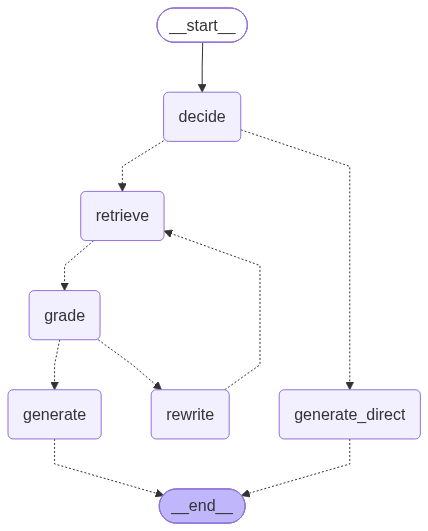

In [15]:
from IPython.display import Image, display

try:
    display(Image(rag_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(Diagram render needs internet access: {e})\nFalling back to text form:\n")
    print(rag_graph.get_graph().draw_mermaid())


## 13 · Example executions and outputs

Four questions, four different paths through the graph. Watch the `[decide]` / `[retrieve]` /
`[grade]` / `[rewrite]` / `[generate]` print lines — they're the graph narrating its own
routing decisions as it makes them, the same live-state-changes idea from the LangGraph-II
notebook, applied to a single agent instead of a team.

### 13.1 — a question that needs no retrieval at all


In [16]:
def ask(question: str) -> dict:
    t0 = time.time()
    result = rag_graph.invoke({"question": question, "retries": 0})
    print(f"\n[{time.time() - t0:.1f}s total]")
    return result

r1 = ask("Good morning!")
print("\nANSWER:", r1["answer"])


  [decide] 'DIRECT.' -> answering directly, no retrieval



[4.1s total]

ANSWER: Morning! Ready to dive into some AI-agent research papers. What's on your agenda today?


### 13.2 — a question that retrieves successfully on the first try

In [17]:
r2 = ask("What are the three main components of the CRAG algorithm, and what does each one do?")
print("\nANSWER:", r2["answer"])


  [decide] 'RETRIEVE' -> searching the knowledge base
  [retrieve] query='What are the three main components of the CRAG algorithm, and what does each one do?' -> 5 chunks: crag_2401.15884.pdfp8, crag_2401.15884.pdfp2, crag_2401.15884.pdfp1, crag_2401.15884.pdfp5, crag_2401.15884.pdfp6


  [grade] verdict='SUFFICIENT' -> sufficient=True (retries so far=0)


  [generate] produced a grounded answer (493 chars, from 5 passages)

[28.7s total]

ANSWER: The three main components of the CRAG algorithm are:

1. Retrieval Evaluator (E) [source p.1]
2. Query Rewriter (W) [source p.1]
3. Generator (G) [source p.1]

Each one does:

1. Retrieval Evaluator (E) evaluates the relevance of each pair (x, di) [source p.1]
2. Query Rewriter (W) rewrites the query x for searching [source p.6]
3. Generator (G) generates a response y [source p.1]

Note: The passages do not explicitly state what the Generator (G) does, only that it generates a response y.


### 13.3 — a question that needs the retry loop

The raw question below doesn't use the exact vocabulary the paper uses, so the first search
comes back short — watch for the `[rewrite]` line, and notice the final answer is still
correctly grounded and cited even though it took more than one attempt to get there.


In [18]:
r3 = ask("How does Self-RAG decide, at inference time, whether it even needs to retrieve anything before answering?")
print("\nANSWER:", r3["answer"])


  [decide] 'RETRIEVE' -> searching the knowledge base
  [retrieve] query='How does Self-RAG decide, at inference time, whether it even needs to retrieve anything before answering?' -> 5 chunks: selfrag_2310.11511.pdfp6, selfrag_2310.11511.pdfp4, selfrag_2310.11511.pdfp3, selfrag_2310.11511.pdfp1, selfrag_2310.11511.pdfp20


  [grade] verdict='INSUFFICIENT' -> sufficient=False (retries so far=0)


  [rewrite] 'How does Self-RAG decide, at inference time, whether it even needs to retrieve anything before answering?'
            -> "How does Self-RAG's retrieval mechanism determine the necessity of information retrieval at inference time?"
  [retrieve] query="How does Self-RAG's retrieval mechanism determine the necessity of information retrieval at inference time?" -> 5 chunks: selfrag_2310.11511.pdfp6, selfrag_2310.11511.pdfp4, selfrag_2310.11511.pdfp9, crag_2401.15884.pdfp9, selfrag_2310.11511.pdfp2


  [grade] verdict='INSUFFICIENT' -> sufficient=False (retries so far=1)


  [rewrite] "How does Self-RAG's retrieval mechanism determine the necessity of information retrieval at inference time?"
            -> "How does Self-RAG's retrieval mechanism employ contextualized embedding alignment and information retrieval necessity estimation at inference time?"
  [retrieve] query="How does Self-RAG's retrieval mechanism employ contextualized embedding alignment and information retrieval necessity estimation at inference time?" -> 5 chunks: selfrag_2310.11511.pdfp6, selfrag_2310.11511.pdfp4, crag_2401.15884.pdfp9, selfrag_2310.11511.pdfp1, selfrag_2310.11511.pdfp1


  [grade] verdict='INSUFFICIENT' -> sufficient=False (retries so far=2)
  [grade] hit the retry limit (2) — generating an honest answer from what we have


  [generate] produced a grounded answer (213 chars, from 5 passages)

[76.2s total]

ANSWER: Self-RAG decides, at inference time, whether it needs to retrieve anything before answering by dynamically deciding when to retrieve text passages based on a threshold, as described in [selfrag_2310.11511.pdf p4].


### 13.4 — a question the knowledge base genuinely cannot answer

This is the scenario that matters most. Every rewrite attempt will fail, on purpose — nothing in
these five papers says anything about TensorFlow. Watch what the system does when it runs out of
retries: it does **not** fall back on the model's general knowledge and guess. It says, grounded
in the fact that it searched and found nothing relevant, that the knowledge base doesn't cover
this.


In [19]:
r4 = ask("According to these papers, what programming language was the original TensorFlow framework written in?")
print("\nANSWER:", r4["answer"])


  [decide] 'RETRIEVE' -> searching the knowledge base
  [retrieve] query='According to these papers, what programming language was the original TensorFlow framework written in?' -> 5 chunks: crag_2401.15884.pdfp12, autogen_2308.08155.pdfp11, adaptiverag_2403.14403.pdfp10, react_2210.03629.pdfp12, selfrag_2310.11511.pdfp14


  [grade] verdict='INSUFFICIENT' -> sufficient=False (retries so far=0)


  [rewrite] 'According to these papers, what programming language was the original TensorFlow framework written in?'
            -> 'TensorFlow original framework implementation language'
  [retrieve] query='TensorFlow original framework implementation language' -> 5 chunks: adaptiverag_2403.14403.pdfp10, autogen_2308.08155.pdfp14, autogen_2308.08155.pdfp1, crag_2401.15884.pdfp12, autogen_2308.08155.pdfp11


  [grade] verdict='INSUFFICIENT' -> sufficient=False (retries so far=1)


  [rewrite] 'TensorFlow original framework implementation language'
            -> 'TensorFlow original framework implementation language and programming paradigm'
  [retrieve] query='TensorFlow original framework implementation language and programming paradigm' -> 5 chunks: adaptiverag_2403.14403.pdfp10, crag_2401.15884.pdfp12, autogen_2308.08155.pdfp11, autogen_2308.08155.pdfp14, autogen_2308.08155.pdfp5


  [grade] verdict='INSUFFICIENT' -> sufficient=False (retries so far=2)
  [grade] hit the retry limit (2) — generating an honest answer from what we have


  [generate] produced a grounded answer (77 chars, from 5 passages)

[103.4s total]

ANSWER: The original TensorFlow framework was not mentioned in the passages provided.


### 13.5 — side by side

The real payoff of everything above: four genuinely different questions, and four genuinely
different amounts of work done to answer them, decided entirely at runtime.


In [20]:
summary = [
    ("Good morning!", r1),
    ("CRAG's three components", r2),
    ("Self-RAG's retrieval decision", r3),
    ("TensorFlow (out of corpus)", r4),
]
print(f"{'Question':38s} {'Retrieved?':11s} {'Retries':8s} Answer (truncated)")
print("-" * 110)
for label, r in summary:
    retrieved = "yes" if r.get("retrieved") else "no"
    retries = r.get("retries", 0)
    preview = r["answer"].replace("\n", " ")[:55]
    print(f"{label:38s} {retrieved:11s} {retries:<8d} {preview}...")


Question                               Retrieved?  Retries  Answer (truncated)
--------------------------------------------------------------------------------------------------------------
Good morning!                          no          0        Morning! Ready to dive into some AI-agent research pape...
CRAG's three components                yes         0        The three main components of the CRAG algorithm are:  1...
Self-RAG's retrieval decision          yes         2        Self-RAG decides, at inference time, whether it needs t...
TensorFlow (out of corpus)             yes         2        The original TensorFlow framework was not mentioned in ...


## Recap

* **Retrieval is a decision, not a default.** The `decide` node means every question pays the
  cost of a search only when a search might actually help — and we deliberately biased that
  decision toward retrieving when uncertain, because the two kinds of mistake are not equally
  costly.
* **Getting results back is not the same as getting the right results back.** The `grade` node
  is what turns "we searched" into "we searched, and it actually worked" — the same distinction
  Session 33 drew between hit rate and a metric that actually matters.
* **A failed search is informative, not fatal.** `rewrite` uses *why* the first attempt likely
  fell short (vocabulary mismatch, usually) to try a better-targeted query — informed
  retries, not blind repetition of the same query.
* **Every loop needs a state-tracked exit.** `retries` plus `MAX_RETRIES` is what keeps the
  rewrite loop from spinning forever on an unanswerable question.
* **Grounded includes knowing what you don't know.** The TensorFlow example is the whole point
  of this notebook in miniature: exhausting every retry and still saying "not covered" is the
  *correct* behaviour, not a failure of the system.

### Suggested exercises

1. Upgrade `grade_node` to CRAG's real three-way judgement (Correct / Ambiguous / Incorrect)
   and add a fourth branch: on "Incorrect," skip the local rewrite loop entirely and answer
   using only the model's own knowledge, clearly labelled as ungrounded — a fully local stand-in
   for CRAG's web-search fallback.
2. Change `K` (chunks retrieved per search) from 5 to 3 and to 10, and re-run Section 13.3 and
   13.4. Does a smaller *k* make the "insufficient" verdict more common? Does a larger one ever
   change a genuinely out-of-corpus question into a false "sufficient"?
3. Add a `sources_cited` field to `RAGState`, populate it in `generate_node` by parsing out the
   `[source p.N]` tags from the answer, and print it alongside the answer — a lightweight,
   fully-local citation-faithfulness check in the spirit of the RAGAS evaluation Session 33's
   guide points toward.
4. Combine the two notebooks: wrap this entire RAG graph as a **tool** a LangGraph-II-style
   supervisor can call, and add a human-in-the-loop step that shows a person the grounded answer
   — with its cited sources — before it's sent back to the user.


## References

**LangGraph / LangChain documentation (current, as of August 2026):**

* [LangGraph Agentic RAG tutorial](https://docs.langchain.com/oss/python/langgraph/agentic-rag) — Docs by LangChain — the official `generate_query_or_respond` / grade / rewrite pattern this notebook adapts for a local model
* [LangGraph](https://langchain-ai.github.io/langgraph/) `1.2.x` / [LangChain](https://python.langchain.com) `1.3.x`

**Papers (figures reproduced under `figures/`, see `figures/ATTRIBUTIONS.md`):**

* Asai, A., Wu, Z., Wang, Y., Sil, A., & Hajishirzi, H. (2023). *Self-RAG: Learning to Retrieve,
  Generate, and Critique through Self-Reflection.* [arXiv:2310.11511](https://arxiv.org/abs/2310.11511)
* Yan, S.-Q., Gu, J.-C., Zhu, Y., & Ling, Z.-H. (2024). *Corrective Retrieval Augmented
  Generation.* [arXiv:2401.15884](https://arxiv.org/abs/2401.15884)
* Jeong, S., Baek, J., Cho, S., Hwang, S. J., & Park, J. C. (2024). *Adaptive-RAG: Learning to
  Adapt Retrieval-Augmented Large Language Models through Question Complexity.*
  [arXiv:2403.14403](https://arxiv.org/abs/2403.14403)
* Wu, Q. et al. (2023). *AutoGen: Enabling Next-Gen LLM Applications via Multi-Agent
  Conversation.* [arXiv:2308.08155](https://arxiv.org/abs/2308.08155) — part of the local
  knowledge base ingested in Section 3
* Yao, S. et al. (2022). *ReAct: Synergizing Reasoning and Acting in Language Models.*
  [arXiv:2210.03629](https://arxiv.org/abs/2210.03629) — part of the local knowledge base
  ingested in Section 3

**Tools used:**

* [Ollama](https://ollama.com) — local LLM + embedding serving (`llama3.2:3b`, `nomic-embed-text`)
* [Chroma](https://www.trychroma.com) — local, embedded vector store
* [PyMuPDF](https://pymupdf.readthedocs.io) — local PDF text extraction


## Teaching transcript — word-by-word script for Session 37b

Same convention as the first notebook: read this close to verbatim your first couple of times
teaching it, then let it become your own. *Italics* are stage directions.

---

### Opening

Welcome back. Second half of Session 37 — Agentic RAG. Quick show of hands: who here has built
a RAG pipeline before, even a simple one? *(pause)* Good — then you already know the standard
shape: embed the question, grab the top few chunks, stuff them in a prompt, generate. That
pipeline has a blind spot, and it's the same blind spot every time: it has no way to notice when
it didn't work. It retrieves *something* — nearest-neighbour search always returns its top-*k*,
even when nothing relevant exists — and it generates *something* from that, confidently, whether
or not it should have.

Today we fix that by putting the model in charge of three decisions it's normally not allowed
to make: whether to search at all, whether what came back is actually good enough, and what to
do about it when it isn't. That's the whole definition of "agentic" here — not a fancier model,
just more decision points, each one a real branch in the graph rather than a step that always
runs.

*(Screen: Section 0. Run it.)* Two local models this time — the chat model you already know,
plus `nomic-embed-text` for embeddings. Confirm both are listed before moving on.

---

### Section 1 — Introduction to Agentic RAG

*(Screen: the Self-RAG figure)*

Look at the right panel of this figure, specifically the bottom example. "Write an essay of
your best summer vacation" — and there's a box that says **No Retrieval**. That's the detail I
want you to sit with: a well-designed RAG system doesn't just retrieve well, it recognizes when
retrieval was never the right move. The top example on the right shows the opposite case —
retrieval on demand, and every retrieved passage individually judged relevant or not, supported
or not. Self-RAG did this by training reflection tokens directly into the model. We're going to
get the same *behavior* — not the same training — using ordinary LangGraph control flow and a
model we didn't train at all. That's worth saying plainly: architecture can substitute for
training, in exactly this kind of case.

---

### Section 2 — Traditional vs. Agentic RAG

*(Screen: the comparison table)*

Read the "on a genuinely unanswerable question" row out loud — it's the one that matters most.
Traditional RAG confidently generates *something* from whatever it retrieved. Agentic RAG can
say "I don't know, and here's why I'm confident I don't know" — because it actually checked
first. You're going to watch that exact contrast happen live in Section 13.

---

### Section 3 — Local document ingestion

*(Screen: Section 3, the load_pdf_pages cell)*

Our knowledge base isn't toy text files — it's five real papers, the same ones cited throughout
both of today's notebooks. Run this cell. *(Run it, read the per-paper counts aloud.)* A hundred
and thirty-seven real pages, loaded straight from PDF with PyMuPDF, each one tagged with which
paper and which page it came from. That page-level tag matters — hold onto it, it's what lets
every answer later cite exactly where it came from.

---

### Section 4 — Chunking and embeddings

*(Screen: Section 4)*

A whole page is too blunt a unit — it mixes ideas. We split with `RecursiveCharacterTextSplitter`,
same tool as the RAG Pipeline Lab: paragraph boundaries first, then sentences, only cutting
mid-word as an absolute last resort. Run the split. *(Run it.)* A hundred and thirty-seven pages
became — read the number out loud — chunks. Now run the embedding cell.

*(Run the embedding dimensionality cell.)* Seven hundred sixty-eight numbers. That's the entire
meaning of that chunk of text, as far as the embedding model is concerned — a point in a
768-dimensional space. Two chunks that mean similar things land near each other in that space;
that's the entire mechanism similarity search relies on.

---

### Section 5 — Local vector store

*(Screen: Section 5, the Chroma build cell — this is the one that can take a few minutes)*

Chroma is an embedded vector database — no server, just a folder on disk. Run this cell now,
because it's the one slow step in the whole notebook. *(If you followed the prep advice and ran
this the day before, say so explicitly:)* I ran this ahead of time, so we're reconnecting to an
already-built index rather than re-embedding from scratch — that's what "reusing existing index"
means in the output. If you're running this cold, expect a few minutes; that's real CPU work
embedding real text, and it only ever has to happen once per corpus.

*(Run the sanity-check search.)* Ask it something and look at what comes back — real passages,
tagged with real page numbers, from a question we never typed into a search box, just embedded
and compared.

---

### Section 6 — Retriever tool

*(Screen: Section 6)*

Same `@tool` pattern from this morning's notebook. This is the whole trick that makes retrieval
optional rather than mandatory: it's just a function the agent *can* call, not a step wired
unconditionally into a pipeline.

---

### Section 7 — Agent decision: retrieve or answer directly

*(Screen: Section 7 markdown, then the decide_node cell)*

Read the "biased toward retrieving" paragraph with the class, and pause on the actual sentence:
*"when the two mistakes cost that differently, the threshold shouldn't sit in the middle."* This
is a real engineering decision, not a throwaway line — an unnecessary local search costs a
fraction of a second; a skipped necessary search costs you a hallucination. Ask the room: can
you think of a system where you'd want the threshold to lean the *other* way — toward answering
directly more often? *(A fair answer: something where an unnecessary search is genuinely
expensive — a paid external API, a slow enterprise search system, a rate-limited service. The
right threshold depends on what a wrong retrieval and a wrong skip each actually cost you.)*

*(Run the decide cell, including the two test lines at the bottom.)* "Good morning" — DIRECT.
"What are the main ideas behind CRAG" — RETRIEVE. Exactly the two outcomes we designed for.

---

### Section 8 — Retrieval and relevance evaluation

*(Screen: the CRAG figure)*

This is the figure the grading step is directly modelled on. Trace the diagram: retrieval
evaluator looks at the documents, asks "are these correct for this query," and routes three
ways — Correct, Ambiguous, Incorrect — with a genuinely different downstream action for each.
We simplified that to two outcomes. Say why, honestly: a three-way judgement is harder for a 3B
model to make consistently, and without a web-search tool we don't have a different action for
two of CRAG's three branches anyway — so the extra complexity wouldn't have earned its keep
*today*. Point at the exercises: hooking up a real web search and restoring the full three-way
split is a natural next step, not a limitation of the approach.

*(Run the grade_node cell.)*

---

### Section 9 — Query rewriting

*(Screen: the Adaptive-RAG figure)*

Panel C is the one to point at: a classifier decides the retrieval *strategy* before anything
is searched — none, single-shot, or iterative. Our Section 7 decide step is a simplified version
of exactly that idea, made before the first search. This section is the complementary piece —
what happens when a single retrieval attempt turns out, only *after* trying it, not to have been
the right call. Two adaptation points, not one: before searching, and after seeing what came
back.

*(Run the rewrite_node cell.)*

---

### Section 10 — The retry / retrieval loop

*(Screen: Section 10 markdown)*

Say this rule out loud, clearly, because it generalises past this one notebook: **a cycle in a
graph needs an explicit, state-tracked exit condition, or it isn't a loop, it's an infinite one
waiting for the right input to trigger it.** `retries` and `MAX_RETRIES` are doing that job here.
Ask the room: what would happen if we deleted that check? *(Answer: the TensorFlow question in
Section 13.4 would rewrite and re-search forever, because there's nothing in the corpus to ever
satisfy the grader.)*

---

### Section 11 — Final grounded answer

*(Screen: Section 11)*

Two instructions in that prompt matter more than the others: cite every claim, and — this one's
easy to miss — don't hedge by default. A grounded answer isn't a nervous one. It should sound
exactly as confident as the evidence actually is: fully confident when the passages clearly say
so, and plainly honest about a gap when they don't. You're about to see both registers, back to
back.

---

### Section 12 — Complete working example

*(Screen: Section 12, build + diagram)*

Six nodes, no checkpointer — nothing here pauses for a human, so nothing needs to survive being
paused. Mention, briefly: if you wanted to bolt a human-in-the-loop approval onto this before
`generate` — "check this grounded answer before it goes to the user" — it's the exact same
`interrupt()` mechanism from this morning's notebook, dropped in front of one more node. Run the
diagram cell.

---

### Section 13 — Example executions and outputs

*(Screen: 13.1)*

Four questions, and I want you to predict the path each one takes before we run it. First one:
"Good morning." *(Run it.)* Straight to a direct answer — no retrieval line at all in the log.

*(Screen: 13.2)*

"What are the three main components of the CRAG algorithm." *(Run it.)* Retrieves, grades
sufficient on the very first attempt, answers — and look, it correctly names all three:
Retrieval Evaluator, Query Rewriter, Generator, each cited to a page.

*(Screen: 13.3 — slow down here)*

Now the interesting one. Read the question with the class before running it: "How does Self-RAG
decide, at inference time, whether it even needs to retrieve anything before answering?" That's
a real question about a real mechanism in the corpus — but phrased in plain English, not paper
vocabulary. Run it, and watch the `[rewrite]` lines scroll by. *(Point at each rewritten query as
it appears.)* The system is trying different phrasings, closer each time to how the paper
actually talks about this — "adaptive retrieval," "threshold." Look at the final answer: it's
correct, and it's cited, and it took real effort inside the graph to get there — effort you just
watched happen, not effort I'm asking you to take on faith.

*(Screen: 13.4 — this is the one to really land)*

Last question, and tell the room plainly before running it: nothing in these five papers
mentions TensorFlow. This question is unanswerable from this knowledge base, on purpose. *(Run
it. Let all three rewrite attempts play out — don't rush this.)* Three different phrasings, three
searches, three "insufficient" verdicts. And now the final line: *(read it aloud, slowly)* "The
original TensorFlow framework was not mentioned in the passages provided." That is the entire
thesis of this notebook in one sentence. It didn't guess. It didn't reach for what a general
knowledge model might know about TensorFlow. It searched, honestly, three different ways, and
when none of them worked, it said so.

*(Screen: 13.5, the summary table)*

Four questions, side by side: zero retrievals for one, one retrieval for another, two retries
for the last two — and every single one of those numbers was a decision the graph made at
runtime, not a script we wrote in advance for each question.

---

### Closing

Two notebooks, one thread connecting them: neither system got smarter by using a bigger model.
Both got more capable by giving the graph real branches, real state, and real stopping
conditions — a place to pause for a human this morning, a place to admit "I don't know" this
afternoon. That's the actual skill Session 37 was about: not prompting harder, engineering the
structure around the prompt. Take these two notebooks, swap in your own tools, your own
documents, your own approval steps — the architecture underneath travels.
